# Decision Tree — Strategy A: SMOTE Oversampling

A Decision Tree classifier is trained using SMOTE oversampling to handle class imbalance. The model is tuned using stratified cross-validation, with SMOTE applied only within the training folds. Hyperparameter tuning focuses on limiting tree complexity through parameters such as maximum depth, minimum samples per split, and minimum samples per leaf to reduce overfitting.

In [19]:
import numpy as np
import pandas as pd
import shap
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [20]:
X_train_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_train_final.parquet")
X_test_final = pd.read_parquet("../DATASETS/PREPROCESSED/X_test_final.parquet")

y_train = pd.read_parquet("../DATASETS/PREPROCESSED/y_train.parquet")["diabetes"]
y_test = pd.read_parquet("../DATASETS/PREPROCESSED/y_test.parquet")["diabetes"]

In [21]:
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

param_grid = {
    "model__criterion": ["gini"],
    "model__max_depth": [7],
    "model__min_samples_split": [20],
    "model__min_samples_leaf": [1],
    "model__max_features": [None]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_final, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV ROC AUC:", grid_search.best_score_)

Fitting 10 folds for each of 1 candidates, totalling 10 fits
Best parameters: {'model__criterion': 'gini', 'model__max_depth': 7, 'model__max_features': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 20}
Best CV ROC AUC: 0.7607566533119815


## Final Test Set Evaluation

After hyperparameter tuning, the best model is evaluated on the held-out test set. The test set is not resampled and therefore preserves the original class distribution. Performance is assessed using accuracy, precision, recall, F1-score, ROC AUC, and the confusion matrix.

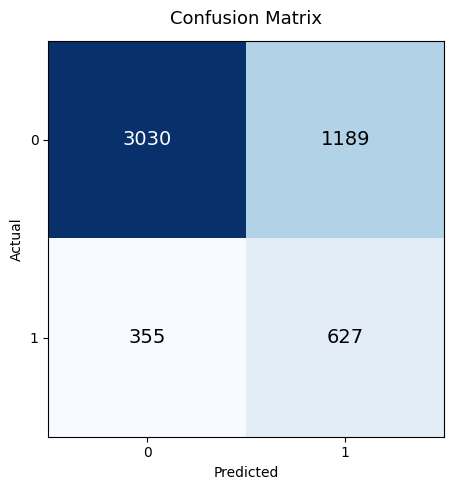

In [22]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_final)

y_pred_proba = best_model.predict_proba(X_test_final)[:, 1]

conf_matrix = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

ax.set_title("Confusion Matrix", color="black", fontsize=13, pad=12)
ax.set_xlabel("Predicted", color="black")
ax.set_ylabel("Actual", color="black")
ax.tick_params(colors="black")

for text in disp.text_.ravel():
    text.set_color("black")
    text.set_fontsize(14)
disp.text_[0, 0].set_color("white")

plt.tight_layout()
plt.show()

In [23]:
# Results

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7031
ROC AUC: 0.7557
Confusion Matrix:
[[3030 1189]
 [ 355  627]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.72      0.80      4219
         1.0       0.35      0.64      0.45       982

    accuracy                           0.70      5201
   macro avg       0.62      0.68      0.62      5201
weighted avg       0.79      0.70      0.73      5201



## Exporting Model Results

The final evaluation metrics are exported to a CSV file so they can be combined later in a separate model comparison notebook. This avoids retraining models when creating summary tables and visualizations.

In [24]:
metrics = {

    "Strategy": "SMOTE",

    "Model": "Decision Tree",

    "Accuracy": accuracy_score(y_test, y_pred),

    "Precision": precision_score(y_test, y_pred),

    "Recall": recall_score(y_test, y_pred),

    "F1-score": f1_score(y_test, y_pred),

    "ROC AUC": roc_auc_score(y_test, y_pred_proba)

}

metrics_df = pd.DataFrame([metrics])

metrics_df.to_csv("../RESULTS/PERFORMANCE/decision_tree_oversampling_metrics.csv", index=False)

## XAI Feature Importance

- SHAP
- Permutation importance
- Built-in Decision Tree feature importance

All results are exported for cross-model comparison.

## SHAP

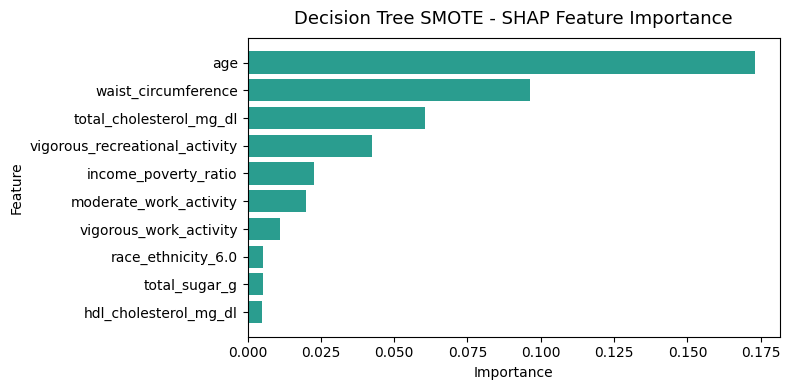

,model,strategy,method,feature,importance,rank
0,Decision Tree,SMOTE,SHAP,age,0.172904,1
3,Decision Tree,SMOTE,SHAP,waist_circumference,0.096231,2
14,Decision Tree,SMOTE,SHAP,total_cholesterol_mg_dl,0.060560,3
11,Decision Tree,SMOTE,SHAP,vigorous_recreational_activity,0.042439,4
1,Decision Tree,SMOTE,SHAP,income_poverty_ratio,0.022576,5
9,Decision Tree,SMOTE,SHAP,moderate_work_activity,0.019978,6
8,Decision Tree,SMOTE,SHAP,vigorous_work_activity,0.011151,7
30,Decision Tree,SMOTE,SHAP,race_ethnicity_6.0,0.005339,8
21,Decision Tree,SMOTE,SHAP,total_sugar_g,0.005240,9
15,Decision Tree,SMOTE,SHAP,hdl_cholesterol_mg_dl,0.005054,10


In [ ]:
# SHAP feature importance
shap_explainer = shap.TreeExplainer(best_model.named_steps["model"] )
shap_values = shap_explainer.shap_values(X_test_final)[:, :, 1]

shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test_final.columns)
shap_rank = shap_importance.rank(ascending=False, method="first").astype(int)

shap_df = pd.DataFrame({
    "model": "Decision Tree",
    "strategy": "SMOTE",
    "method": "SHAP",
    "feature": shap_importance.index,
    "importance": shap_importance.values,
    "rank": shap_rank.values
})

# Store to CSV
shap_df = shap_df[["model", "strategy", "method", "feature", "importance", "rank"]].sort_values("rank")
shap_df.to_csv("../RESULTS/FEATURE/decision_tree_SMOTE_shap.csv", index=False)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
top_shap = shap_df.head(10).sort_values("importance")
ax.barh(top_shap["feature"], top_shap["importance"], color="#2a9d8f")
ax.set_title("Decision Tree SMOTE - SHAP Feature Importance", color="black", fontsize=13, pad=10)
ax.set_xlabel("Importance", color="black")
ax.set_ylabel("Feature", color="black")
ax.tick_params(colors="black")
plt.tight_layout()
plt.show()

shap_df

## Permutation

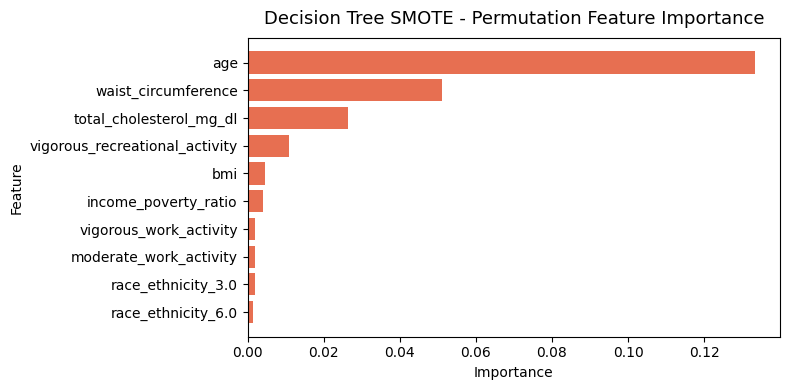

,model,strategy,method,feature,importance,rank
0,Decision Tree,SMOTE,Permutation,age,0.133270,1
3,Decision Tree,SMOTE,Permutation,waist_circumference,0.051158,2
14,Decision Tree,SMOTE,Permutation,total_cholesterol_mg_dl,0.026476,3
11,Decision Tree,SMOTE,Permutation,vigorous_recreational_activity,0.011027,4
2,Decision Tree,SMOTE,Permutation,bmi,0.004571,5
1,Decision Tree,SMOTE,Permutation,income_poverty_ratio,0.003980,6
8,Decision Tree,SMOTE,Permutation,vigorous_work_activity,0.001998,7
9,Decision Tree,SMOTE,Permutation,moderate_work_activity,0.001968,8
28,Decision Tree,SMOTE,Permutation,race_ethnicity_3.0,0.001963,9
30,Decision Tree,SMOTE,Permutation,race_ethnicity_6.0,0.001316,10


In [ ]:
# Permutation feature importance

perm_result = permutation_importance(
    estimator=best_model,
    X=X_test_final,
    y=y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(perm_result.importances_mean, index=X_test_final.columns)
perm_rank = perm_importance.rank(ascending=False, method="first").astype(int)

perm_df = pd.DataFrame({
    "model": "Decision Tree",
    "strategy": "SMOTE",
    "method": "Permutation",
    "feature": perm_importance.index,
    "importance": perm_importance.values,
    "rank": perm_rank.values
})

# Store to CSV
perm_df = perm_df[["model", "strategy", "method", "feature", "importance", "rank"]].sort_values("rank")
perm_df.to_csv("../RESULTS/FEATURE/decision_tree_SMOTE_permutation.csv", index=False)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
top_perm = perm_df.head(10).sort_values("importance")
ax.barh(top_perm["feature"], top_perm["importance"], color="#e76f51")
ax.set_title("Decision Tree SMOTE - Permutation Feature Importance", color="black", fontsize=13, pad=10)
ax.set_xlabel("Importance", color="black")
ax.set_ylabel("Feature", color="black")
ax.tick_params(colors="black")
plt.tight_layout()
plt.show()

perm_df

## Built in

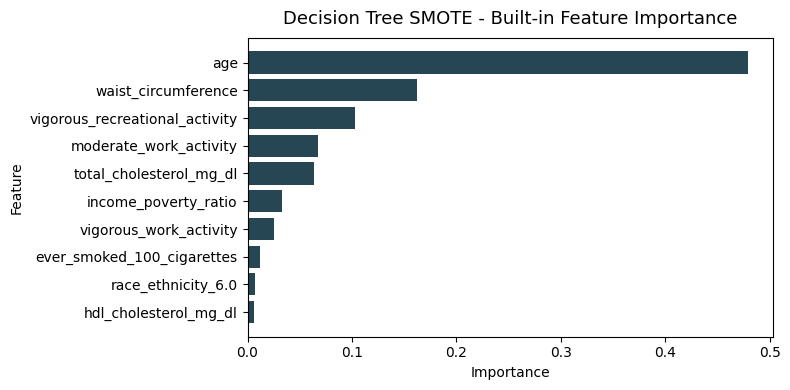

,model,strategy,method,feature,importance,rank
0,Decision Tree,SMOTE,Built-in,age,0.479274,1
3,Decision Tree,SMOTE,Built-in,waist_circumference,0.161867,2
11,Decision Tree,SMOTE,Built-in,vigorous_recreational_activity,0.103293,3
9,Decision Tree,SMOTE,Built-in,moderate_work_activity,0.067331,4
14,Decision Tree,SMOTE,Built-in,total_cholesterol_mg_dl,0.063623,5
1,Decision Tree,SMOTE,Built-in,income_poverty_ratio,0.033458,6
8,Decision Tree,SMOTE,Built-in,vigorous_work_activity,0.024961,7
6,Decision Tree,SMOTE,Built-in,ever_smoked_100_cigarettes,0.011494,8
30,Decision Tree,SMOTE,Built-in,race_ethnicity_6.0,0.007104,9
15,Decision Tree,SMOTE,Built-in,hdl_cholesterol_mg_dl,0.006535,10


In [ ]:
# Built-in feature importance

builtin_importance = pd.Series(best_model.named_steps["model"].feature_importances_, index=X_test_final.columns)
builtin_rank = builtin_importance.rank(ascending=False, method="first").astype(int)

builtin_df = pd.DataFrame({
    "model": "Decision Tree",
    "strategy": "SMOTE",
    "method": "Built-in",
    "feature": builtin_importance.index,
    "importance": builtin_importance.values,
    "rank": builtin_rank.values
})

# Store to CSV
builtin_df = builtin_df[["model", "strategy", "method", "feature", "importance", "rank"]].sort_values("rank")
builtin_df.to_csv("../RESULTS/FEATURE/decision_tree_SMOTE_builtin.csv", index=False)

# Visualization
fig, ax = plt.subplots(figsize=(8, 4))
top_builtin = builtin_df.head(10).sort_values("importance")
ax.barh(top_builtin["feature"], top_builtin["importance"], color="#264653")
ax.set_title("Decision Tree SMOTE - Built-in Feature Importance", color="black", fontsize=13, pad=10)
ax.set_xlabel("Importance", color="black")
ax.set_ylabel("Feature", color="black")
ax.tick_params(colors="black")
plt.tight_layout()
plt.show()

builtin_df